# Final Project Helper Functions

Helper functions for loading and plotting spark spreads at **HB_HOUSTON** and **HB_WEST**.

| Location | Electricity Hub | Gas Hub | Gas Adder |
|----------|----------------|---------|----------|
| Houston  | HB_HOUSTON | Houston Ship Channel (HSC) | +\$3.00/MMBtu (toll + VOM) |
| West     | HB_WEST    | Waha                       | None |

Heat rate: **9.5 MMBtu/MWh** (simple-cycle turbine, 9500 BTU/kWh)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

HEAT_RATE = 9.5   # MMBtu/MWh
HOU_ADDER = 3.0   # $/MMBtu — Houston toll + variable O&M

In [2]:
def load_texas_gas(path, sheet_name):
    """
    Load a Texas gas hub price series from teas_nat_gas.xlsx.
    sheet_name : 'HSC' for Houston Ship Channel, 'Waha' for West Texas
    Returns DataFrame with columns: Date, Gas_Price
    """
    df = pd.read_excel(path, sheet_name=sheet_name, skiprows=6,
                       header=None, names=['Date', 'Gas_Price', 'Chg'])
    df = df[pd.to_numeric(df['Date'], errors='coerce').notna()].copy()
    df['Date']      = pd.to_datetime(df['Date'].astype(int), unit='D', origin='1899-12-30')
    df['Gas_Price'] = pd.to_numeric(df['Gas_Price'], errors='coerce')
    return df[['Date', 'Gas_Price']].dropna().sort_values('Date').reset_index(drop=True)


def load_ercot_dam(path, hub):
    """
    Load ERCOT DAM hourly prices and aggregate to daily averages for one hub.
    hub : 'HB_HOUSTON' or 'HB_WEST'
    Returns DataFrame with columns: Date, Elec_Mean
    """
    raw = pd.concat(pd.read_excel(path, sheet_name=None).values(), ignore_index=True)
    raw['Delivery Date'] = pd.to_datetime(raw['Delivery Date'])
    daily = (raw[raw['Settlement Point'] == hub]
             .groupby(pd.Grouper(key='Delivery Date', freq='D'))['Settlement Point Price']
             .mean()
             .reset_index()
             .rename(columns={'Delivery Date': 'Date', 'Settlement Point Price': 'Elec_Mean'}))
    return daily


def build_spark_spread(gas_df, elec_df, heat_rate, gas_adder=0.0):
    """
    Merge gas and power data and compute daily spark spread.
    Spark Spread = Elec_Mean - (Gas_Price + gas_adder) * heat_rate
    """
    df = elec_df.merge(gas_df, on='Date', how='inner')
    df['Spark_Spread'] = df['Elec_Mean'] - (df['Gas_Price'] + gas_adder) * heat_rate
    return df.sort_values('Date').reset_index(drop=True)

In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────

GAS_PATH   = 'data/teas_nat_gas.xlsx'
ERCOT_PATH = 'data/rpt.00013060.0000000000000000.DAMLZHBSPP_2025.xlsx'

houston = build_spark_spread(
    load_texas_gas(GAS_PATH, 'HSC'),
    load_ercot_dam(ERCOT_PATH, 'HB_HOUSTON'),
    HEAT_RATE, gas_adder=HOU_ADDER
)

west = build_spark_spread(
    load_texas_gas(GAS_PATH, 'Waha'),
    load_ercot_dam(ERCOT_PATH, 'HB_WEST'),
    HEAT_RATE, gas_adder=0.0
)

print(f"Houston: {len(houston)} days  |  West: {len(west)} days")
houston[['Date', 'Elec_Mean', 'Gas_Price', 'Spark_Spread']].tail(3)

Houston: 236 days  |  West: 236 days


,Date,Elec_Mean,Gas_Price,Spark_Spread
233,2025-12-10,33.286250,4.15,-34.638750
234,2025-12-11,27.445833,3.89,-38.009167
235,2025-12-12,35.680000,3.47,-25.785000


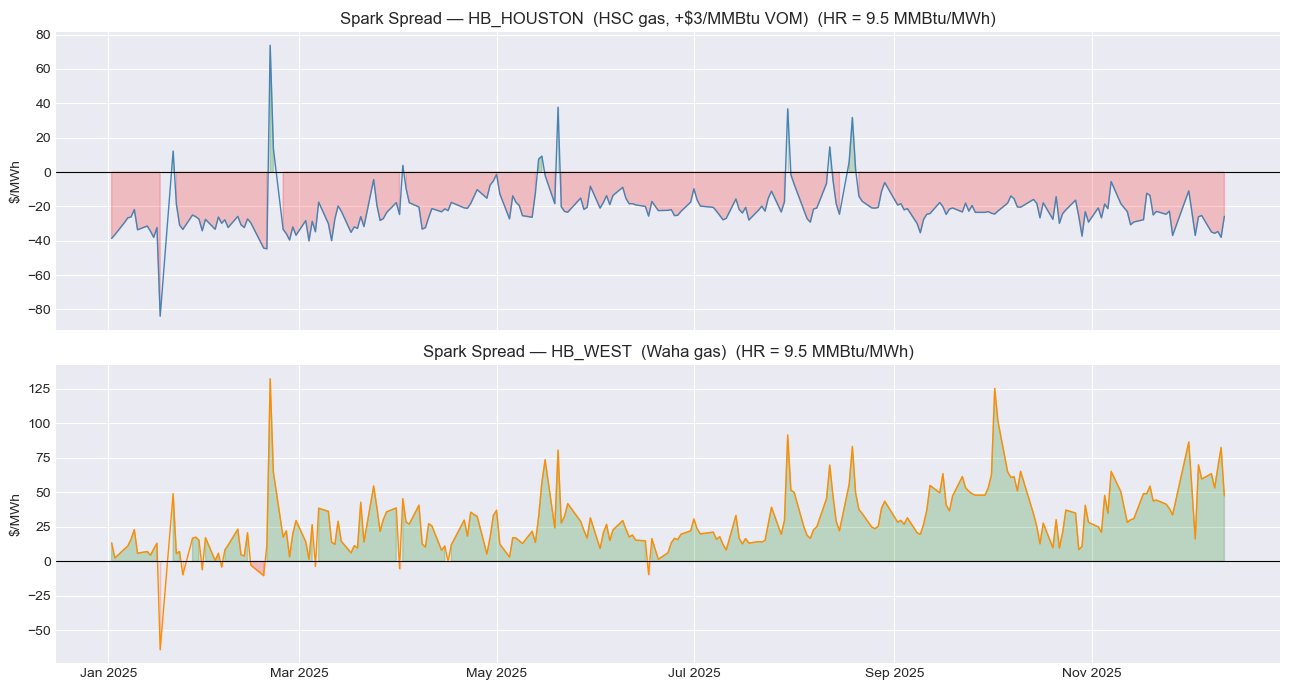

In [4]:
# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for ax, df, label, color in [
    (axes[0], houston, 'HB_HOUSTON  (HSC gas, +$3/MMBtu VOM)', 'steelblue'),
    (axes[1], west,    'HB_WEST  (Waha gas)',                   'darkorange'),
]:
    ss = df['Spark_Spread'].values
    ax.plot(df['Date'], ss, color=color, linewidth=1)
    ax.fill_between(df['Date'], ss, 0, where=ss >= 0, alpha=0.2, color='green')
    ax.fill_between(df['Date'], ss, 0, where=ss <  0, alpha=0.2, color='red')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('$/MWh')
    ax.set_title(f'Spark Spread — {label}  (HR = {HEAT_RATE} MMBtu/MWh)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()